# Enrichment and transformations

## 1. Загрузка JSON-файла из ex02

In [534]:
import pandas as pd
import numpy as np


input_file = '../data/auto.json'

df = pd.read_json(input_file)

pd.options.display.float_format = '{:,.2f}'.format

df

,CarNumber,Refund,Fines,Make,Model
0,Y163O8161RUS,2,"3,200.00",Ford,Focus
1,E432XX77RUS,1,"6,500.00",Toyota,Camry
2,7184TT36RUS,1,"2,100.00",Ford,Focus
3,X582HE161RUS,2,"2,000.00",Ford,Focus
4,92918M178RUS,1,"5,700.00",Ford,Focus
...,...,...,...,...,...
720,Y163O8161RUS,2,"1,600.00",Ford,Focus
721,M0309X197RUS,1,"22,300.00",Ford,Focus
722,O673E8197RUS,2,600.00,Ford,Focus
723,8610T8154RUS,1,"2,000.00",Ford,Focus


## 2. Обогащение датафрейма

- Создание выборки из 200 новых наблюдений, используя random_state = 21

In [535]:
random_state = 21
sampleSize = 200

sampled_cars = df[["CarNumber", "Make", "Model"]].drop_duplicates().sample(n=sampleSize, random_state=random_state, ignore_index=True)


sampled_cars = sampled_cars.assign(
    Refund=np.random.choice(df["Refund"].dropna(), 200),
    Fines=np.random.choice(df["Fines"].dropna(), 200)
)

sampled_cars

,CarNumber,Make,Model,Refund,Fines
0,704787163RUS,Ford,Focus,2,"1,000.00"
1,E34877152RUS,Ford,Focus,1,"3,100.00"
2,O50699163RUS,Ford,Focus,2,"9,900.00"
3,O753MX161RUS,Ford,Focus,2,"13,900.00"
4,9583EY178RUS,Ford,Focus,1,"45,000.00"
...,...,...,...,...,...
195,8182XX154RUS,Ford,Focus,1,"1,400.00"
196,T6418M116RUS,Ford,Focus,1,800.00
197,E42377152RUS,Ford,Focus,1,"3,000.00"
198,C514X938RUS,Ford,Focus,1,"1,000.00"


- Объединение выборки с исходным датафреймом

In [536]:
concat_rows = pd.concat([df, sampled_cars], ignore_index=True)

concat_rows

,CarNumber,Refund,Fines,Make,Model
0,Y163O8161RUS,2,"3,200.00",Ford,Focus
1,E432XX77RUS,1,"6,500.00",Toyota,Camry
2,7184TT36RUS,1,"2,100.00",Ford,Focus
3,X582HE161RUS,2,"2,000.00",Ford,Focus
4,92918M178RUS,1,"5,700.00",Ford,Focus
...,...,...,...,...,...
920,8182XX154RUS,1,"1,400.00",Ford,Focus
921,T6418M116RUS,1,800.00,Ford,Focus
922,E42377152RUS,1,"3,000.00",Ford,Focus
923,C514X938RUS,1,"1,000.00",Ford,Focus


## 3. Дополнение concat_rows новым столбцом, содержащим сгенерированные данные

- Создание ряда "Years"

In [537]:
np.random.seed(21)

year_series = pd.Series(np.random.randint(1980, 2020, concat_rows.shape[0]))

fines = concat_rows

fines["Year"] = year_series

fines

,CarNumber,Refund,Fines,Make,Model,Year
0,Y163O8161RUS,2,"3,200.00",Ford,Focus,1989
1,E432XX77RUS,1,"6,500.00",Toyota,Camry,1995
2,7184TT36RUS,1,"2,100.00",Ford,Focus,1984
3,X582HE161RUS,2,"2,000.00",Ford,Focus,2015
4,92918M178RUS,1,"5,700.00",Ford,Focus,2014
...,...,...,...,...,...,...
920,8182XX154RUS,1,"1,400.00",Ford,Focus,1981
921,T6418M116RUS,1,800.00,Ford,Focus,1992
922,E42377152RUS,1,"3,000.00",Ford,Focus,2007
923,C514X938RUS,1,"1,000.00",Ford,Focus,2005


## 4. Обогащение датафрейма данными из другого датафрейма

- Создание нового датафрейма с номерами автомобилей и их владельцами

In [538]:
random_state = 21

json_file = '../../datasets/surname.json'

df_surnames = pd.read_json(json_file)

df_surnames.columns = df_surnames.iloc[0]
df_surnames = df_surnames[1:].reset_index(drop=True)

df_surnames = df_surnames[["NAME"]]

df_surnames.rename(columns={"NAME": "SURNAME"}, inplace=True)

owners = pd.DataFrame(fines[["CarNumber"]].drop_duplicates())
owners["SURNAME"] = df_surnames.sample(n=len(owners), random_state=random_state, replace=True)["SURNAME"].values

owners

,CarNumber,SURNAME
0,Y163O8161RUS,RICHARDSON
1,E432XX77RUS,ROSS
2,7184TT36RUS,MORGAN
3,X582HE161RUS,BAILEY
4,92918M178RUS,LOPEZ
...,...,...
715,O136HO197RUS,CAMPBELL
719,O22097197RUS,HALL
721,M0309X197RUS,BAKER
722,O673E8197RUS,DIAZ


- Добавление пяти наблюдений в fines

In [539]:
new_rows_f = pd.DataFrame(
    {'CarNumber': ['Z000ZZ76RUS', 'B111BB76RUS', 'L222LL76RUS', 'X333XX76RUS', 'T444TT76RUS'], 
    'Refund': [1, 2, 3, 4, 5],
    'Fines': [1400, 100, 333, 219, 100000],
    'Make': ["Ford", "Lada", "SAAB", "Citroen", "Chevrolet"], 
    'Model': ["Focus", "Granta", "900 turbo", "GT", "Camaro"], 
    'Year': [1981, 1999, 2000, 2001, 2002]
    })

fines = pd.concat([fines, new_rows_f], ignore_index=True)

fines

,CarNumber,Refund,Fines,Make,Model,Year
0,Y163O8161RUS,2,"3,200.00",Ford,Focus,1989
1,E432XX77RUS,1,"6,500.00",Toyota,Camry,1995
2,7184TT36RUS,1,"2,100.00",Ford,Focus,1984
3,X582HE161RUS,2,"2,000.00",Ford,Focus,2015
4,92918M178RUS,1,"5,700.00",Ford,Focus,2014
...,...,...,...,...,...,...
925,Z000ZZ76RUS,1,"1,400.00",Ford,Focus,1981
926,B111BB76RUS,2,100.00,Lada,Granta,1999
927,L222LL76RUS,3,333.00,SAAB,900 turbo,2000
928,X333XX76RUS,4,219.00,Citroen,GT,2001


- Удаление последних 20 наблюдений из owners датафрейма и добавление трех новых наблюдений, которые не совпадают с наблюдениями, добавленными в fines датафрейме.

In [540]:
owners = owners.iloc[:-19]

new_rows_o = pd.DataFrame(
    {"CarNumber": ["A555AA76RUS", "C666CC76RUS", "D777DD76RUS"],
     "SURNAME": ["BAGGENS", "PARCKER", "UIZLY"]
    })

owners = pd.concat([owners, new_rows_o])

owners

,CarNumber,SURNAME
0,Y163O8161RUS,RICHARDSON
1,E432XX77RUS,ROSS
2,7184TT36RUS,MORGAN
3,X582HE161RUS,BAILEY
4,92918M178RUS,LOPEZ
...,...,...
686,7608EE777RUS,HILL
687,X583HE161RUS,KING
0,A555AA76RUS,BAGGENS
1,C666CC76RUS,PARCKER


- Объединение двух датафреймов

    - Новый фрейм данных должен содержать только те номера автомобилей, которые существуют в обоих фреймах данных.

In [541]:
merge_inner = fines.merge(owners, on="CarNumber", how='inner')

merge_inner


,CarNumber,Refund,Fines,Make,Model,Year,SURNAME
0,Y163O8161RUS,2,"3,200.00",Ford,Focus,1989,RICHARDSON
1,E432XX77RUS,1,"6,500.00",Toyota,Camry,1995,ROSS
2,7184TT36RUS,1,"2,100.00",Ford,Focus,1984,MORGAN
3,X582HE161RUS,2,"2,000.00",Ford,Focus,2015,BAILEY
4,92918M178RUS,1,"5,700.00",Ford,Focus,2014,LOPEZ
...,...,...,...,...,...,...,...
898,8182XX154RUS,1,"1,400.00",Ford,Focus,1981,SMITH
899,T6418M116RUS,1,800.00,Ford,Focus,1992,RUIZ
900,E42377152RUS,1,"3,000.00",Ford,Focus,2007,CARTER
901,C514X938RUS,1,"1,000.00",Ford,Focus,2005,RAMIREZ


In [542]:
merge_outer = pd.merge(fines, owners, on="CarNumber", how='outer')

merge_outer

,CarNumber,Refund,Fines,Make,Model,Year,SURNAME
0,704687163RUS,2.00,"1,400.00",Ford,Focus,"2,004.00",ADAMS
1,704687163RUS,1.00,500.00,Ford,Focus,"2,005.00",ADAMS
2,704787163RUS,2.00,"2,800.00",Ford,Focus,"1,992.00",MORGAN
3,704787163RUS,2.00,"1,000.00",Ford,Focus,"1,985.00",MORGAN
4,704987163RUS,2.00,"8,594.59",Ford,Focus,"1,985.00",MITCHELL
...,...,...,...,...,...,...,...
928,Y973O8197RUS,2.00,"8,594.59",Ford,Focus,"2,005.00",YOUNG
929,Y973O8197RUS,1.00,"34,800.00",Ford,Focus,"2,003.00",YOUNG
930,Y973O8197RUS,1.00,"69,600.00",Ford,Focus,"2,017.00",YOUNG
931,Y973O8197RUS,2.00,"16,200.00",Ford,Focus,"2,017.00",YOUNG


In [543]:
merge_left = pd.merge(fines, owners, on="CarNumber", how='left')

merge_left

,CarNumber,Refund,Fines,Make,Model,Year,SURNAME
0,Y163O8161RUS,2,"3,200.00",Ford,Focus,1989,RICHARDSON
1,E432XX77RUS,1,"6,500.00",Toyota,Camry,1995,ROSS
2,7184TT36RUS,1,"2,100.00",Ford,Focus,1984,MORGAN
3,X582HE161RUS,2,"2,000.00",Ford,Focus,2015,BAILEY
4,92918M178RUS,1,"5,700.00",Ford,Focus,2014,LOPEZ
...,...,...,...,...,...,...,...
925,Z000ZZ76RUS,1,"1,400.00",Ford,Focus,1981,NaN
926,B111BB76RUS,2,100.00,Lada,Granta,1999,NaN
927,L222LL76RUS,3,333.00,SAAB,900 turbo,2000,NaN
928,X333XX76RUS,4,219.00,Citroen,GT,2001,NaN


In [544]:
merge_right = pd.merge(fines, owners, on="CarNumber", how='right')

merge_right

,CarNumber,Refund,Fines,Make,Model,Year,SURNAME
0,Y163O8161RUS,2.00,"3,200.00",Ford,Focus,"1,989.00",RICHARDSON
1,Y163O8161RUS,2.00,"1,600.00",Ford,Focus,"1,980.00",RICHARDSON
2,E432XX77RUS,1.00,"6,500.00",Toyota,Camry,"1,995.00",ROSS
3,E432XX77RUS,2.00,"13,000.00",Toyota,Camry,"2,018.00",ROSS
4,7184TT36RUS,1.00,"2,100.00",Ford,Focus,"1,984.00",MORGAN
...,...,...,...,...,...,...,...
901,7608EE777RUS,1.00,"4,000.00",Skoda,Octavia,"2,000.00",HILL
902,X583HE161RUS,1.00,"3,000.00",Ford,Focus,"1,984.00",KING
903,A555AA76RUS,NaN,NaN,NaN,NaN,NaN,BAGGENS
904,C666CC76RUS,NaN,NaN,NaN,NaN,NaN,PARCKER


## 5. Создание сводной таблицы на основе fines датафрейма


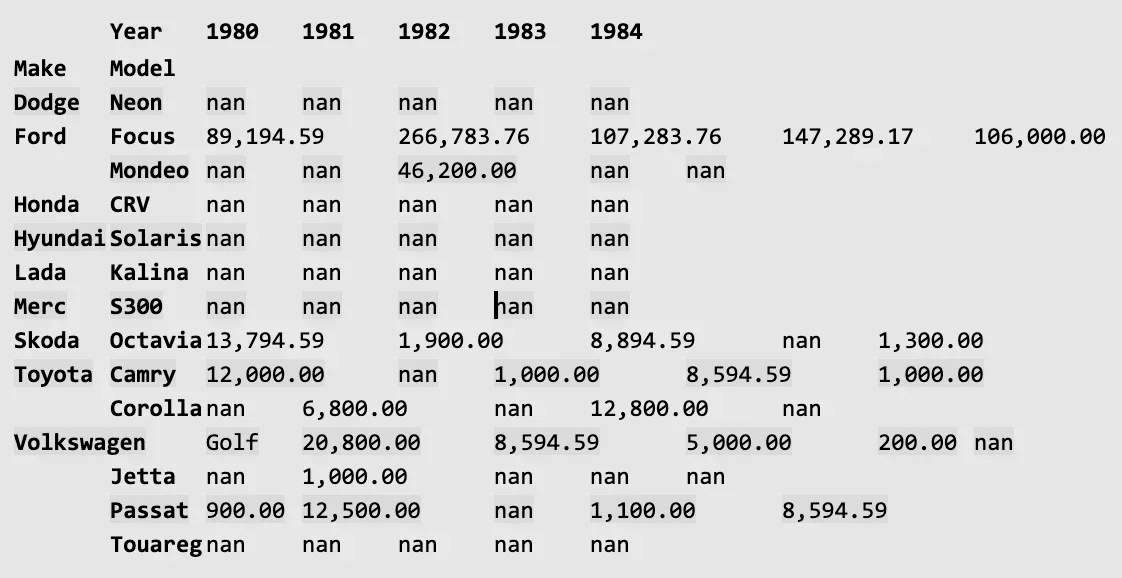

In [545]:
fines.pivot_table(index=['Make', 'Model'], values="Fines", columns="Year", aggfunc=sum)

/tmp/ipykernel_909186/488775408.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  fines.pivot_table(index=['Make', 'Model'], values="Fines", columns="Year", aggfunc=sum)


Year                       1980       1981       1982      1983       1984  \
Make       Model                                                             
Chevrolet  Camaro           NaN        NaN        NaN       NaN        NaN   
Citroen    GT               NaN        NaN        NaN       NaN        NaN   
Ford       Focus     167,994.59 404,589.17 186,778.35 66,000.00 116,994.59   
           Mondeo           NaN        NaN        NaN       NaN        NaN   
Lada       Granta           NaN        NaN        NaN       NaN        NaN   
SAAB       900 turbo        NaN        NaN        NaN       NaN        NaN   
Skoda      Octavia    20,500.00  10,900.00   6,900.00 12,594.59   7,200.00   
Toyota     Camry      20,594.59   8,594.59        NaN  7,200.00        NaN   
           Corolla          NaN        NaN   2,000.00       NaN        NaN   
Volkswagen Golf       32,700.00        NaN        NaN  8,594.59     300.00   
           Jetta            NaN        NaN        NaN       NaN        NaN   
           Passat           NaN   1,600.00        NaN  3,200.00  10,000.00   
           Touareg          NaN        NaN        NaN       NaN        NaN   

Year                       1985      1986      1987       1988      1989  ...  \
Make       Model                                                          ...   
Chevrolet  Camaro           NaN       NaN       NaN        NaN       NaN  ...   
Citroen    GT               NaN       NaN       NaN        NaN       NaN  ...   
Ford       Focus     134,483.76 88,094.59 92,400.00 178,094.59 69,200.00  ...   
           Mondeo           NaN       NaN       NaN        NaN  8,600.00  ...   
Lada       Granta           NaN       NaN       NaN        NaN       NaN  ...   
SAAB       900 turbo        NaN       NaN       NaN        NaN       NaN  ...   
Skoda      Octavia    10,294.59    600.00  5,200.00   3,000.00 91,400.00  ...   
Toyota     Camry            NaN       NaN       NaN        NaN 22,400.00  ...   
           Corolla          NaN    800.00  8,000.00        NaN  4,000.00  ...   
Volkswagen Golf       24,000.00       NaN  9,300.00        NaN  5,800.00  ...   
           Jetta            NaN       NaN       NaN        NaN       NaN  ...   
           Passat      5,000.00 15,000.00 12,300.00        NaN  8,300.00  ...   
           Touareg     5,800.00       NaN       NaN        NaN       NaN  ...   

Year                       2010      2011      2012       2013       2014  \
Make       Model                                                            
Chevrolet  Camaro           NaN       NaN       NaN        NaN        NaN   
Citroen    GT               NaN       NaN       NaN        NaN        NaN   
Ford       Focus     111,189.17 97,083.76 96,300.00 150,089.17 120,394.59   
           Mondeo           NaN       NaN 34,400.00        NaN   7,500.00   
Lada       Granta           NaN       NaN       NaN        NaN        NaN   
SAAB       900 turbo        NaN       NaN       NaN        NaN        NaN   
Skoda      Octavia     5,500.00    500.00    500.00  12,594.59     300.00   
Toyota     Camry            NaN       NaN  8,594.59        NaN        NaN   
           Corolla    24,000.00  8,594.59       NaN   2,100.00        NaN   
Volkswagen Golf        8,594.59    300.00       NaN        NaN        NaN   
           Jetta            NaN       NaN       NaN   4,700.00        NaN   
           Passat      2,800.00       NaN       NaN        NaN        NaN   
           Touareg     6,300.00       NaN       NaN        NaN   1,300.00   

Year                       2015      2016       2017       2018      2019  
Make       Model                                                           
Chevrolet  Camaro           NaN       NaN        NaN        NaN       NaN  
Citroen    GT               NaN       NaN        NaN        NaN       NaN  
Ford       Focus     242,500.00 75,994.59 315,900.00 299,494.59 93,494.59  
           Mondeo           NaN 46,200.00        NaN        NaN       NaN  
L

## 6. Сохрание fines и owners в CSV-файлы без индекса

In [546]:
fines.to_csv('../data/fines.csv', sep='\t', index=False)
owners.to_csv('../data/owners.csv', sep='\t', index=False)